In [1]:
from prophet import Prophet
from prophet.plot import add_changepoints_to_plot
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv('airline_passengers.csv',index_col='Month',parse_dates=True)

In [3]:
df.head()

,Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


In [4]:
df.columns=['y']

In [6]:
df['ds']=df.index

In [7]:
df.head()

,y,ds
Month,,
1949-01-01,112,1949-01-01
1949-02-01,118,1949-02-01
1949-03-01,132,1949-03-01
1949-04-01,129,1949-04-01
1949-05-01,121,1949-05-01


In [8]:
df.tail()

,y,ds
Month,,
1960-08-01,606,1960-08-01
1960-09-01,508,1960-09-01
1960-10-01,461,1960-10-01
1960-11-01,390,1960-11-01
1960-12-01,432,1960-12-01


In [9]:
m=Prophet()

In [10]:
m.fit(df)

11:25:35 - cmdstanpy - INFO - Chain [1] start processing
11:25:43 - cmdstanpy - INFO - Chain [1] done processing


In [13]:
future=m.make_future_dataframe(periods=12,freq='Ms')

In [14]:
future.tail()

,ds
151,1960-12-01 00:00:00.008
152,1960-12-01 00:00:00.009
153,1960-12-01 00:00:00.010
154,1960-12-01 00:00:00.011
155,1960-12-01 00:00:00.012


In [15]:
forecast=m.predict(future)

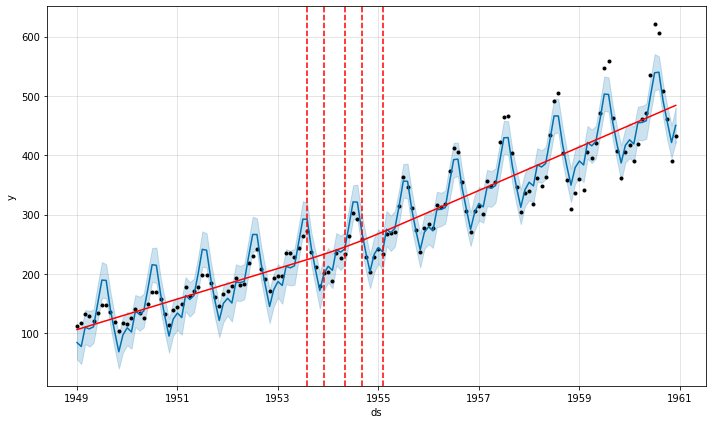

In [16]:
fig=m.plot(forecast);
a=add_changepoints_to_plot(fig.gca(),m,forecast)

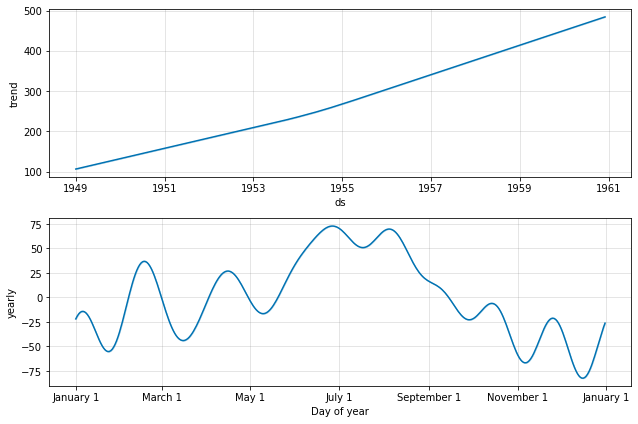

In [18]:
m.plot_components(forecast);

In [19]:
m2=Prophet(seasonality_mode='multiplicative')

In [20]:
m2.fit(df)

11:29:46 - cmdstanpy - INFO - Chain [1] start processing
11:29:46 - cmdstanpy - INFO - Chain [1] done processing


In [21]:
future2=m2.make_future_dataframe(periods=12,freq='Ms')

In [23]:
forecast2=m2.predict(future2)

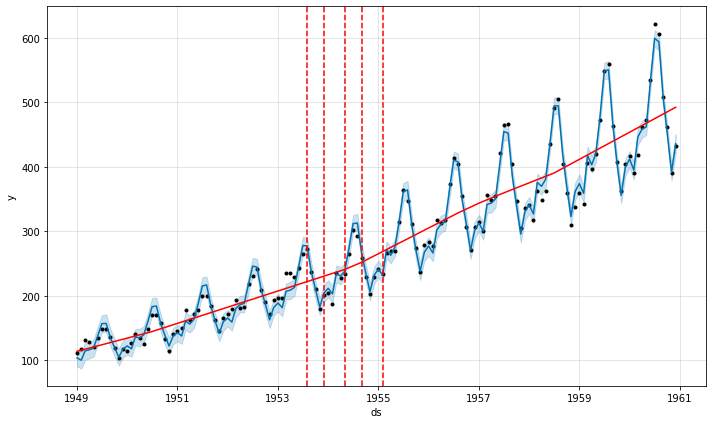

In [24]:
fig=m2.plot(forecast2);
a=add_changepoints_to_plot(fig.gca(),m,forecast2)

In [25]:
logdf=df.copy()
logdf['y']=np.log(logdf['y'])

In [26]:
m3=Prophet()

In [27]:
m3.fit(logdf)

11:33:45 - cmdstanpy - INFO - Chain [1] start processing
11:33:45 - cmdstanpy - INFO - Chain [1] done processing


In [28]:
future3=m3.make_future_dataframe(periods=12,freq='Ms')

In [29]:
forecast3=m3.predict(future3)

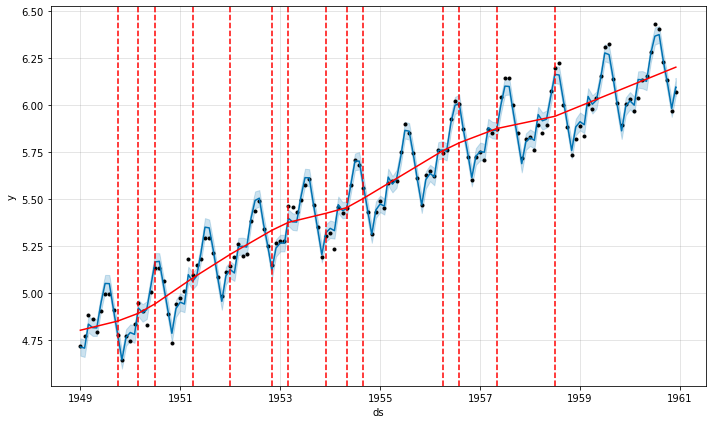

In [32]:
fig=m3.plot(forecast3);
a=add_changepoints_to_plot(fig.gca(),m3,forecast3)

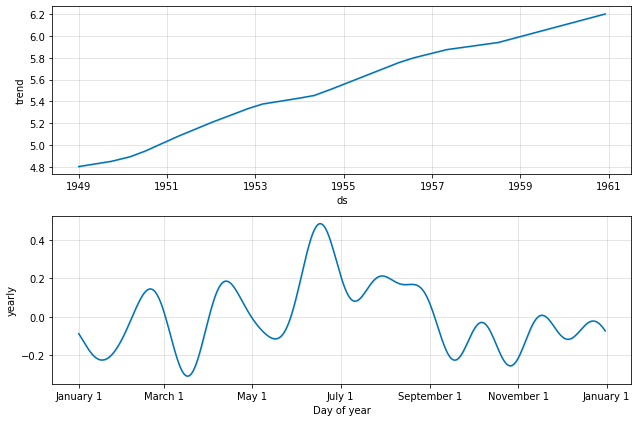

In [31]:
m3.plot_components(forecast3);

Outliers

In [33]:
df.loc['1955-01-01','y']=600
df.loc['1957-06-01','y']=1

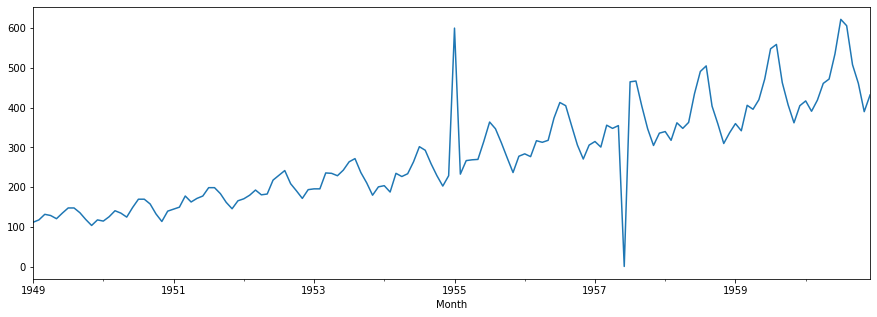

In [34]:
df['y'].plot(figsize=(15,5));

11:42:55 - cmdstanpy - INFO - Chain [1] start processing
11:42:56 - cmdstanpy - INFO - Chain [1] done processing


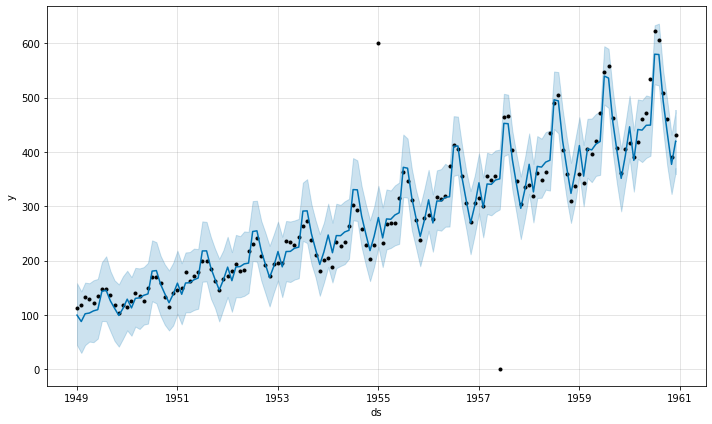

In [37]:
m=Prophet(seasonality_mode='multiplicative')
m.fit(df)
future=m.make_future_dataframe(periods=12,freq='Ms')
forecast=m.predict(future)
m.plot(forecast);

In [38]:
df2=df[~df.index.isin(['1955-01-01','1957-06-01'])]

<AxesSubplot:xlabel='Month'>

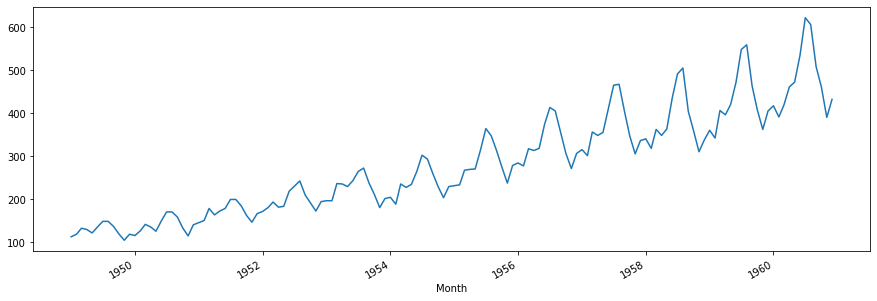

In [39]:
df2['y'].plot(figsize=(15,5))

11:45:03 - cmdstanpy - INFO - Chain [1] start processing
11:45:04 - cmdstanpy - INFO - Chain [1] done processing


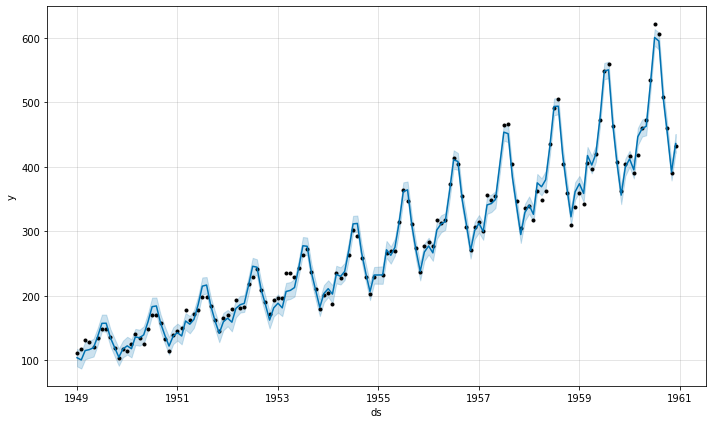

In [40]:
m=Prophet(seasonality_mode='multiplicative')
m.fit(df2)
future=m.make_future_dataframe(periods=12,freq='Ms')
forecast=m.predict(future)
m.plot(forecast);